# bandnorm-rust quickstart

Compute scGAD scores on single-cell Hi-C contact pairs and visualise the
resulting cell embedding.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import bandnorm_rust as bn

ROOT = Path("/scratch/users/steorra/analysis/omicverse_dev/rust-bandnorm")
DATA = ROOT / "tests" / "data"

print("bandnorm-rust:", "0.1.0  | _RUST_AVAILABLE =", bn._RUST_AVAILABLE)


bandnorm-rust: 0.1.0  | _RUST_AVAILABLE = True


## 1. Inputs

Two tables:

* `pairs` — 5 columns (`chrom, binA, binB, count, cell`). One row per binned
  contact pair. Cell name identifies the donor cell.
* `genes` — 5 columns (`chr, s1, s2, strand, gene_name`). Gene table, here
  using mm9 (10180 genes) bundled with the BandNorm R package.


In [2]:
pairs = pd.read_csv(DATA / "scgad_input_pairs.tsv.gz", sep="\t")
genes = pd.read_csv(DATA / "scgad_input_genes.tsv", sep="\t")

print("pairs shape:", pairs.shape, "  cells:", pairs.cell.nunique())
print("genes shape:", genes.shape)
display(pairs.head(3))
display(genes.head(3))


pairs shape: (1290919, 5)   cells: 100
genes shape: (10180, 5)


,chrom,binA,binB,count,cell
0,chr1,3000000,3010000,1,cortex-p028-cb_039.contacts.txt
1,chr1,3060000,3060000,1,cortex-p028-cb_039.contacts.txt
2,chr1,3110000,3110000,1,cortex-p028-cb_039.contacts.txt


,chr,s1,s2,strand,gene_name
0,chr1,3195982,3661579,-,Xkr4
1,chr1,4334224,4350473,-,Rp1
2,chr1,4481009,4486494,-,Sox17


## 2. Run scGAD — gene × cell matrix

`scgad(pairs, genes, resolution, depth_norm=True)` returns a pandas DataFrame
with rows = genes (filtered to non-empty), cols = cells, values = per-gene
Z-scores after column-wise depth normalisation.


In [3]:
bn.set_num_threads(4)

gad = bn.scgad(pairs, genes, resolution=10_000, depth_norm=True)
print("scGAD output:", gad.shape, "  (genes_kept × cells)")
gad.iloc[:5, :3]


scGAD output: (1219, 100)   (genes_kept × cells)


,cortex-p028-cb_039.contacts.txt,cortex-p028-cb_041.contacts.txt,cortex-p028-cb_045.contacts.txt
Xkr4,-0.810022,-1.538694,-0.462696
Rp1,-0.576385,-0.576385,-0.576385
Sox17,-0.519160,-0.519160,-0.519160
Mrpl15,-0.538834,-0.538834,-0.538834
Lypla1,0.098187,-0.113002,-0.975974


## 3. Top variable genes — heatmap

Most informative genes for cell typing are typically the most variable across
the population. Pick the top 50 by row variance and plot.


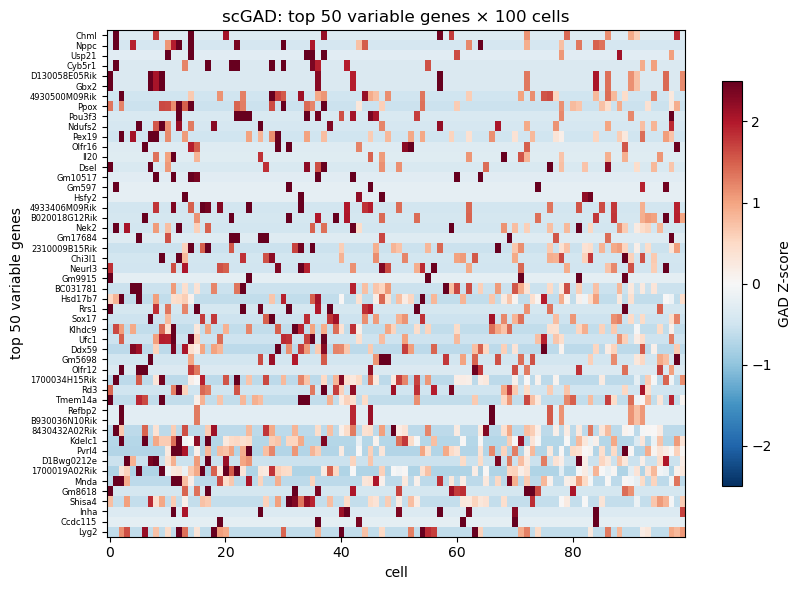

In [4]:
top = gad.var(axis=1).sort_values(ascending=False).head(50).index
fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.imshow(gad.loc[top].to_numpy(),
               aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax.set_yticks(np.arange(len(top))); ax.set_yticklabels(top, fontsize=6)
ax.set_xlabel("cell"); ax.set_ylabel("top 50 variable genes")
plt.colorbar(im, ax=ax, label="GAD Z-score", shrink=0.8)
ax.set_title("scGAD: top 50 variable genes × 100 cells")
plt.tight_layout(); plt.show()


## 4. Cell embedding via PCA → UMAP

Standard scHi-C downstream:
1. Drop NaN rows.
2. PCA on cells × genes (cells as samples).
3. UMAP on the top PCs.

This is the same pipeline `BandNorm::create_embedding()` runs in R, except we
go straight through scanpy/scikit-learn here.


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = gad.dropna().T.to_numpy()  # (cells, genes)
# Standardise gene-wise then PCA.
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=20, random_state=0)
X_pca = pca.fit_transform(X_std)
print(f"PCA: {X_pca.shape}  | explained variance ratio: top-5 = {pca.explained_variance_ratio_[:5]}")

try:
    import umap
    umap_model = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=0)
    X_umap = umap_model.fit_transform(X_pca)
    has_umap = True
except ImportError:
    print("umap-learn not installed — falling back to first 2 PCs.")
    X_umap = X_pca[:, :2]
    has_umap = False

print("embedding:", X_umap.shape)


PCA: (100, 20)  | explained variance ratio: top-5 = [0.04116366 0.0301544  0.02330987 0.02187572 0.01960169]


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


embedding: (100, 2)


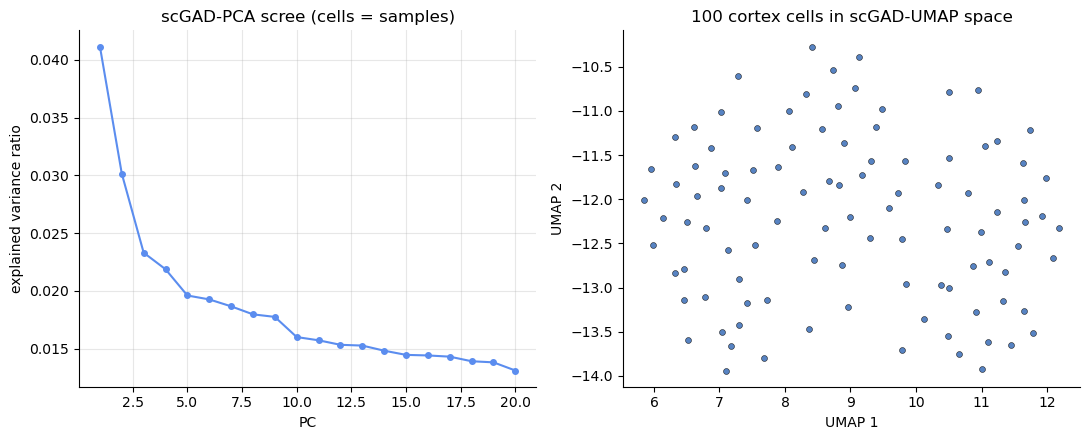

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: PCA scree.
ax = axes[0]
ax.plot(np.arange(1, 21), pca.explained_variance_ratio_, "o-",
        color="#5b8def", markersize=4)
ax.set_xlabel("PC"); ax.set_ylabel("explained variance ratio")
ax.set_title("scGAD-PCA scree (cells = samples)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, alpha=0.3)

# Right: UMAP / 2-PC scatter.
ax = axes[1]
ax.scatter(X_umap[:, 0], X_umap[:, 1], s=18, alpha=0.85,
           c="#3a6db8", edgecolor="black", linewidth=0.4)
label = "UMAP" if has_umap else "PCA"
ax.set_xlabel(f"{label} 1"); ax.set_ylabel(f"{label} 2")
ax.set_title(f"100 cortex cells in scGAD-{label} space")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()


## 5. BandNorm normalisation

The other half of the package — diagonal-aware Hi-C count normalisation. This
divides each contact count by the cell's band depth at that genomic distance,
then scales by the global mean band depth.


input columns : ['chrom', 'binA', 'binB', 'count', 'cell']
output columns: ['chrom', 'binA', 'binB', 'cell', 'diag', 'BandNorm']

first 5 rows after BandNorm:


,chrom,binA,binB,cell,diag,BandNorm
0,chr1,3000000,3010000,cortex-p028-cb_039.contacts.txt,10000,1.168628
1,chr1,3060000,3060000,cortex-p028-cb_039.contacts.txt,0,1.127220
2,chr1,3110000,3110000,cortex-p028-cb_039.contacts.txt,0,1.127220
3,chr1,3170000,3230000,cortex-p028-cb_039.contacts.txt,60000,1.571349
4,chr1,3140000,3260000,cortex-p028-cb_039.contacts.txt,120000,1.556160


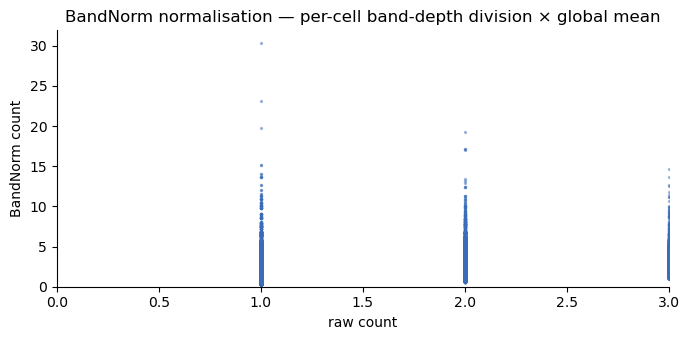

In [7]:
norm_df = bn.bandnorm(pairs)
print("input columns :", list(pairs.columns))
print("output columns:", list(norm_df.columns))
print()
print("first 5 rows after BandNorm:")
display(norm_df.head(5))

# Show that the BandNorm column has different scale than raw count.
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(pairs["count"], norm_df["BandNorm"], s=2, alpha=0.4, color="#3a6db8")
lo, hi = pairs["count"].min(), pairs["count"].quantile(0.999)
ax.set_xlabel("raw count"); ax.set_ylabel("BandNorm count")
ax.set_xlim(0, hi)
ax.set_ylim(0, norm_df["BandNorm"][pairs["count"] <= hi].max() * 1.05)
ax.set_title("BandNorm normalisation — per-cell band-depth division × global mean")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## Summary

* `scgad(pairs, genes)` — gene × cell Z-score matrix, drop-in for
  BandNorm's R `scGAD()`.
* `bandnorm(pairs)` — per-(chrom, diagonal, cell) depth-normalised counts,
  drop-in for R `bandnorm()`.
* Both are bit-equivalent to the R reference (max diff < 1e-13) and
  ~24× faster than the R `sapply` reference.

For multi-process scaling (e.g. `concurrent.futures.ProcessPoolExecutor`),
call `bn.set_num_threads(n)` in each worker initialiser to size rayon
sensibly relative to worker count.
